In [1]:
%matplotlib inline

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
import pyreadstat
import requests
import time
import urllib.request
import os
import gtfs_kit as gk
import zipfile
import statsmodels

In [24]:
import json

In [179]:
import seaborn as sns

In [222]:
import numpy as np

## 1. Data Source Declaration

For the purposes of this project we are going to load two datasets. 

The first data set is the Netherlands National Travel Survey (ODiN - Onderweg in Nederland) for 2023 published by Statistics Netherlands. The dataset is provided by DANS Data Station and can be downloaded via the link: https://ssh.datastations.nl/dataset.xhtml?persistentId=doi:10.17026/SS/FNXJEU. ODiN is a continuous daily survey into the travel behaviour of residents of the Netherlands. Respondents are asked for one specific day of the year to record where they went, with what purpose, with what mode of transport and how long it took. The survey contains many individual trip microdata explaining the used transport mode, the purpose of the trip, the departure and arrival times, various socioeconomics, etc.  

Why we are going to load the data from 2023? The data for 2025 is still not available in hte current month of April 2026 and the data for 2024 is stated by DANS to be with methodological break.    

The second data source is on service level and will be used to calculate the attributes of the alternatives which a person did not choose. We will download the data freely via the OVapi. From this source we get data for the routing infrastructure and provided services. The data is updated daily and free to access. 

### 1.1 ODiN 2023 Data

In [15]:
# Read ODiN 2023 trip-level data
odin_data, meta = pyreadstat.read_sav(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\ODiN2023_Databestand.sav") 
columns = meta.column_labels

In [17]:
odin_data.shape

(211991, 247)

In [20]:
odin_data.head(5)

,OP,OPID,Steekproef,Mode,HHPers,HHSam,HHPlOP,HHLft1,HHLft2,HHLft3,...,RReisduur,RReisduurBL,RVertStat,RAankStat,RTSamen,RCorrSnelh,RVliegVer,FactorH,FactorP,FactorV
0,1.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,20.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
1,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,15.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
2,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
3,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,2.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089
4,0.0,2.700008e+11,4.0,1.0,3.0,3.0,3.0,0.0,0.0,0.0,...,30.0,0.0,000,000,13.0,0.0,0.0,79.014958,237.044874,86521.379089


In [30]:
columns[:10]

['Nieuwe persoon',
 'Uniek id voor iedere OP',
 'Steekproefindicator',
 'Responsmode',
 'Aantal personen in huishouden',
 'Huishoudsamenstelling',
 'Plaats OP in huishouden tov huishoudkern',
 'Aantal huishoudleden jonger dan 6 jaar',
 'Aantal huishoudleden van 6 t/m 11 jaar',
 'Aantal huishoudleden van 12 t/m 17 jaar']

In [205]:
odin_data.OP.sum() #Number of "new people" - survey participants

np.float64(64459.0)

In [211]:
odin_data.VerplID.nunique() #number of unique trip ids (trip entries)

181717

From the above three code blocks we can quickly see the shape of the data (211991 rows and 247 columns) and the number of participants - 64459.

#### ODiN 2023 Data Inspection
The size of dataset is expectedly big but we have another problem we need to solve - the column names. All column names are in Dutch and we need to rename them or at least the ones we are going to process further. 

From the meta data we can obtain all 247 varaibles and its corresponding column names. We can easily translate those columns and save them in a separate dictionaryso we can easily use them to rename the coressponding column in our original dataset.

In [32]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\english_names.txt", 'r', encoding='utf-8') as file:
    english_names = file.read().splitlines()

In [33]:
english_names[:10]

['New person',
 'Unique ID for each respondent',
 'Sample indicator',
 'Response mode',
 'Number of persons in household',
 'Household composition',
 'Position of respondent in household relative to household core',
 'Number of household members under 6 years old',
 'Number of household members aged 6 to 11',
 'Number of household members aged 12 to 17']

Now we are going to just map the dutch column names to english names and save it as a json file. We are going to add also the english column names to the metadata so we can easily refer to each column later. We are going to rename only the relevant columns to English later.

In [52]:
meta.column_labels_en = list(english_names)

In [34]:
column_mapping = dict(zip(odin_data.columns, english_names)) # Dutch to English Mapping

In [55]:
with open(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\column_mapping.json", 'w', encoding='utf-8') as file:
    json.dump(column_mapping, file, ensure_ascii=False, indent=4)

Lets now create two small csv sample files of the ODiNs' dataset and the metadata so we can easily check it and refer to it. 

In [56]:
# Export metadata of the ODIN file so you can inspect the data 
meta_data = pd.DataFrame({
    'column_original': meta.column_names,
    'column_label_dut': meta.column_labels,
    'column_labels_en': meta.column_labels_en,
    'dtype': odin_data.dtypes.values
})
meta_data.to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_metadata.csv", index=False)

# Export a small sample for inspection
odin_data.head(20).to_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\sample\odin\odin_sample.csv", index=False)

Firstly, we are going to inspect the distribution of the key variables from our dataset which will drive our analytical decisions. We will look into trip purpose, main transport mode, residential municipality and weekday. The goal is to observe if there are any major issues with the data which will stop us from further analysis.      

From the meta_data.csv we can easily identify the variable names in dutch and inspect the data. The name of the variables are as per below:


| Variable | Description | Data Type |
| :--- | :--- | :--- |
| `MotiefV` | Trip purpose | `float64` |
| `KHvm` | Main transport mode class | `float64` |
| `Hvm` | Main transport mode | `float64` |
| `WoGem` | Residential municipality | `float64` |
| `Weekdag` | Weekday (1=Sun, 2=Mon ... 7=Sat) | `float64` |
| `Feestdag` | Public holiday flag (0=no, 1=yes) | `float64` |


In [87]:
key_vars = {
    "MotiefV"  : "Trip purpose",
    "KHvm"     : "Class transport mode",
    "Hvm"      : "Main transport mode ",
    "WoGem"    : "Residential Municipality",
    "Weekdag"  : "Day of Week",
    "Feestdag" : "Public holiday flag",
}

n = len(odin_data) 

for col, label in key_vars.items():
    print(f"\n{'='*30}\n {label} [{col}]\n{'='*30}") 
    
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions 
    result = pd.DataFrame({
        "count": (stats * n).astype(int), 
        "pct (%)": (stats * 100).round(2) #
    })
    print(result)


 Trip purpose [MotiefV]
         count  pct (%)
MotiefV                
1.0      33302    15.71
2.0       2724     1.28
3.0       3836     1.81
4.0      12747     6.01
5.0       6084     2.87
6.0      14930     7.04
7.0      41492    19.57
8.0      19649     9.27
9.0      18655     8.80
10.0     18089     8.53
11.0     19280     9.09
12.0      6347     2.99
13.0      3446     1.63
NaN      11410     5.38

 Class transport mode [KHvm]
      count  pct (%)
KHvm                
1.0   62674    29.56
2.0   19785     9.33
3.0   14346     6.77
4.0    9151     4.32
5.0   50586    23.86
6.0   38357    18.09
7.0    5682     2.68
NaN   11410     5.38

 Main transport mode  [Hvm]
      count  pct (%)
Hvm                 
1.0   82459    38.90
2.0   14346     6.77
3.0    4327     2.04
4.0    2224     1.05
5.0    2600     1.23
6.0      15     0.01
7.0   14500     6.84
8.0   36071    17.02
9.0   38357    18.09
10.0    195     0.09
11.0   2358     1.11
12.0    370     0.17
13.0     67     0.03
14.0   

For better visualization and analysis lets parse the codes from the codebook with the variable values from the ODIN dataset. 
We are going to extract the labels from the codebook in a dictionary and parse it with the variables from the ODIN Dataset. 

In [92]:
codebook = pd.read_csv(r"C:\Users\vladimir.koev\OneDrive - Трансметрикс АД\SoftUni\Data Science\Final Exam\data\raw\odin\docs\ODiN2023_Codeboek_v1.0.tab", sep = "\t", header = None, dtype = str, encoding = "latin-1")

In [95]:
codebook = codebook.fillna("").apply(lambda col: col.str.strip().str.strip())

In [97]:
codebook.head(5)

,0,1,2,3,4,5,6,7,8,9,10,11
0,VariabelenaamODiN2023,VariabelelabelODiN2023,Niveau,CodeODiN2023,CodelabelODiN2023,Korteomschrijving,G,H,I,J,K,L
1,OP,Nieuwe persoon,P,,,,,,,,,
2,,,,0,Geen nieuwe persoon,,,,,,,
3,,,,1,Nieuwe persoon,,,,,,,
4,OPID,Uniek id voor iedere OP,P,,,,,,,,,


In [170]:
codelabels = {}
current_var = None

for _, row in codebook.iterrows():
    var = row[0]
    code = row[3]
    desc = row[4]

    if var:
        current_var = var
        codelabels[current_var] = {}

    if current_var and code and code != "<missing>" and desc: 
        try:
            codelabels[current_var][float(code)] = desc
        except ValueError:
            codelabels[current_var][code] = desc

In [171]:
codelabels['MotiefV'] #Quick check if we parsed correctly the labels. 

{1.0: 'Van en naar het werk',
 2.0: 'Zakelijk bezoek in werksfeer',
 3.0: 'Beroepsmatig',
 4.0: 'Afhalen/brengen personen',
 5.0: 'Afhalen/brengen goederen',
 6.0: 'Onderwijs/cursus volgen',
 7.0: 'Winkelen/boodschappen doen',
 8.0: 'Visite/logeren',
 9.0: 'Toeren/wandelen',
 10.0: 'Sport/hobby',
 11.0: 'Overige vrijetijdsbesteding',
 12.0: 'Diensten/persoonlijke verzorging',
 13.0: 'Ander motief'}

In [172]:
#Save the stats results with the labels names (in Dutch) 
results = {}
n = len(odin_data)

for col, label in key_vars.items():
    stats = odin_data[col].value_counts(dropna = False, normalize = True).sort_index() #we normalize to get the proportions
    var_labels = codelabels.get(col, {})
    index_labels = [
        var_labels.get(x, str(int(x)) if x == x else "NaN") if x == x else "NaN"
        for x in stats.index
        ]
    results[col] = pd.DataFrame({
        "label": index_labels,
        "pct" : (stats.values * 100). round(2), #tburn the shares into %
        "count":(stats.values * n),
    })

In [196]:
results.keys()

dict_keys(['MotiefV', 'KHvm', 'Hvm', 'WoGem', 'Weekdag', 'Feestdag'])

In [181]:
results["MotiefV"]

,label,pct,count
0,Van en naar het werk,15.71,33302.0
1,Zakelijk bezoek in werksfeer,1.28,2724.0
2,Beroepsmatig,1.81,3836.0
3,Afhalen/brengen personen,6.01,12747.0
4,Afhalen/brengen goederen,2.87,6084.0
5,Onderwijs/cursus volgen,7.04,14930.0
6,Winkelen/boodschappen doen,19.57,41492.0
7,Visite/logeren,9.27,19649.0
8,Toeren/wandelen,8.80,18655.0
9,Sport/hobby,8.53,18089.0


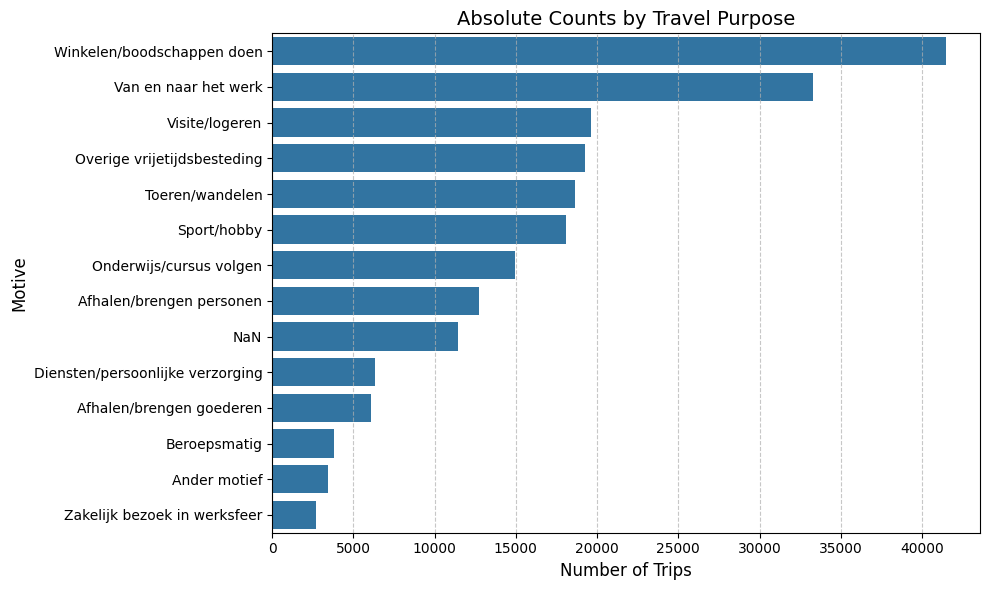

In [202]:
#Obtain Data
plot_motive = results["MotiefV"].sort_values('count', ascending = False)

#Def the plot
plt.figure(figsize=(10, 6))
sns.barplot(
    data = plot_motive, 
    x = 'count', 
    y = 'label', 
    #palette='magma'
)

#Labels
plt.title('Absolute Counts by Travel Purpose', fontsize=14)
plt.xlabel('Number of Trips', fontsize = 12)
plt.ylabel('Motive', fontsize = 12)
plt.grid(axis= 'x', linestyle = '--', alpha = 0.7)

plt.tight_layout()
plt.show()

#### Build Working Set from ODiN 2023
Expectedly, the most common motive for travelling was reported to be "Winkelen/boodschappen doen" which means "Shopping". The second most common motive which is also the purpose of our analysis was reported to be "Van en naar het werk". It is translated to English as "To and From Work" and it counts for nearly 16% of all reported trips. It is important to mention that "NaN" motives are also a significant part of the survey as 5.38% of the participants did not mention their trip purpose.

Before analyzing the dataset further we need to make a working version which contains only the relevant analytical variables. We are going to select 20 variables required to describe a commuting trip. Others are dropped to ease the work and avoid any confusion. To do so we are going to perform the below steps:
1. Select relevant columns from the dataset and rename them to English. (Source for Dutch Names: odin_metadata.csv) 
2. Map the original dutch column names to English names.
3. Drop the remaining variables from the working dataset.   

In [346]:
rename_map = {
    # Identifiers
    "OP" : "new_id", #0- no ; 1= yes
    "OPID" : "person_id",
    "VerplID" : "trip_id",
    "Verpl" : "new_trip_id", # 0 = no, 1 = new trip ; 6 = serries ; 7 = freight trip

    # Geography
    "WoGem" : "home_municipality",
    "VertGem" : "origin_municipality",
    "AankGem" : "dest_municipality",
    "VertPC" : "origin_postcode",
    "AankPC" : "dest_postcode",
    "BuurtAdam" : "amsterdam_neighborhood",

    # Trip characteristics
    "MotiefV" : "trip_purpose", # 1 = commuting ("Van en naar het werk")
    "Hvm" : "mode_detailed", # granular mode code
    "KHvm" : "mode_class", # 1 = car , 4 = PT, 5 = bike
    "HvmRol" : "mode_role", # 1=driver  2 =passenger
    "Maand" : "month",
    "Weekdag" : "weekday", # 2=Mon ... 6=Fri
    "Feestdag" : "is_holiday",
    "VertUur" : "departure_hour",
    "VertMin": "departure_minute",
    "Reisduur" : "travel_time_min",       # total door-to-door minutes
    "AfstV" : "distance_hm",           # trip distnace in hectometers — convert later imto km

    # Person characteristics
    "Leeftijd" : "age",
    "Geslacht" : "gender",                # 1=male, 2=female
    "HHBestInkG" : "income_decile",         # 1 (lowest) to 10 (highest)
    "OPRijbewijsAu" : "has_driving_license",   # 1=yes, 2=no
    "HHAuto" : "n_cars_household",

    # Survey weights
    "FactorV" : "weight_trip", #survey trip weight
    "FactorP" : "weight_person", #survey person weight
}

# Select and rename
work_data = odin_data[rename_map.keys()].rename(columns = rename_map).copy()

In [297]:
work_data.head(5)

,new_id,person_id,trip_id,new_trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,...,departure_minute,travel_time_min,distance_hm,age,gender,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person
0,1.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,363.0,1191,1105,0,...,20.0,20.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
1,0.0,2.700008e+11,2.700008e+13,1.0,437.0,363.0,437.0,1105,1191,0,...,0.0,15.0,36.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
2,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,0.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
3,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,45.0,2.0,1.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874
4,0.0,2.700008e+11,2.700008e+13,1.0,437.0,437.0,437.0,1191,1191,0,...,0.0,30.0,10.0,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874


In [347]:
#convert distance in hectometers to km
hm_to_km = 0.1   # converting coefficient
work_data["distance_km"] = (work_data.distance_hm * hm_to_km).round(3)

In [348]:
#Lets insert a flag when a trip was during peak hours
#AM peak: 07:00h - 09:00h ; 
#PM peak: 17:00h - 19:00h (selected based on the peak definition from Section 1.7)

# --- Peak hour definition ---
am_peak_start = 7
am_peak_end = 9
pm_peak_start = 17
pm_peak_end = 19

work_data["is_peak"] = (
    ((work_data.departure_hour.values >= am_peak_start) & (work_data.departure_hour.values < am_peak_end)) |
    ((work_data.departure_hour.values >= pm_peak_start) & (work_data.departure_hour.values < pm_peak_end))
).astype(np.int8)

In [299]:
# Maps KHvm codes to analytical labels used in all downstream steps
code_car_driver = 1.0
code_pt = 4.0
code_bike = 5.0

mode_label_map = {
    code_car_driver : "car",
    code_pt : "pt", #public transport
    code_bike : "bike",
}
work_data["chosen_mode"] = (work_data.mode_class.map(mode_label_map).astype("category"))

In [300]:
work_data.chosen_mode.value_counts().sort_values() #What mode is chosen the most by people between car, public transport and bike

chosen_mode
pt       9151
bike    50586
car     62674
Name: count, dtype: int64

In [245]:
print(f"Working sample shape: {work_data.shape}")
print(f"\nColumns retained ({len(work_data.columns)}):")
print(list(work_data.columns))
print(f"\nSample (5 rows):")
work_data.head(5)

Working sample shape: (211991, 29)

Columns retained (29):
['new_id', 'person_id', 'trip_id', 'home_municipality', 'origin_municipality', 'dest_municipality', 'origin_postcode', 'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose', 'mode_detailed', 'mode_class', 'mode_role', 'weekday', 'is_holiday', 'departure_hour', 'departure_minute', 'travel_time_min', 'distance_hm', 'age', 'gender', 'income_decile', 'has_driving_license', 'n_cars_household', 'weight_trip', 'weight_person', 'distance_km', 'is_peak', 'chosen_mode']

Sample (5 rows):


,new_id,person_id,trip_id,home_municipality,origin_municipality,dest_municipality,origin_postcode,dest_postcode,amsterdam_neighborhood,trip_purpose,...,age,gender,income_decile,has_driving_license,n_cars_household,weight_trip,weight_person,distance_km,is_peak,chosen_mode
0,1.0,2.700008e+11,2.700008e+13,437.0,437.0,363.0,1191,1105,0,12.0,...,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,3.6,1,car
1,0.0,2.700008e+11,2.700008e+13,437.0,363.0,437.0,1105,1191,0,12.0,...,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,3.6,0,car
2,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,0.1,0,NaN
3,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,7.0,...,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,0.1,0,NaN
4,0.0,2.700008e+11,2.700008e+13,437.0,437.0,437.0,1191,1191,0,9.0,...,59.0,1.0,6.0,1.0,2.0,86521.379089,237.044874,1.0,0,NaN


## Dataset Filtering  and Scoping Down the Analysis

From the Codebook file in the repository we see that the origin ODiN file contains information on 7 different transport modes. Firstly, we will start by examine the distribution of those 7 transport modes for all Amsterdam commuters. From the Codebook we can see that the ODiN dataset contains two analytical variables for transport mode: 
1. `mode_detailed`- detailed transport mode (Hvm)
2. `mode_class`- transport mode class (KHvm)

Lets examine the trip distribution  based on these two variables. For the purpose, we are going to apply only the trip purpose and geography filters (commuting in Amsterdam).

In [349]:
weekday_codes = [2.0, 3.0, 4.0, 5.0, 6.0]   # Monday to Friday
amsterdam_gem_code = 363 #Amsterdam area code
commute_code = 1.0    # 1 = "Van en naar het werk" (commuting)

base_mask = (
    (work_data.home_municipality == amsterdam_gem_code) &
    (work_data.trip_purpose == commute_code) &
    (work_data.weekday.isin(weekday_codes)) &
    (work_data.is_holiday == 0)
    ) 

base_amst_data = work_data[base_mask].copy()
print(f"Amsterdam commuting trips (all modes): {len(base_amst_data):,}")

Amsterdam commuting trips (all modes): 1,389


In [307]:
base_amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'weekday', 'is_holiday',
       'departure_hour', 'departure_minute', 'travel_time_min', 'distance_hm',
       'age', 'gender', 'income_decile', 'has_driving_license',
       'n_cars_household', 'weight_trip', 'weight_person', 'is_peak',
       'chosen_mode'],
      dtype='object')

=== Detailed transport mode — Amsterdam commuting ===
Mode (Detailed)  Count  Share(%)
            Car    249      17.9
          Train    276      19.9
            Bus     71       5.1
           Tram     49       3.5
          Metro    172      12.4
         E-bike     76       5.5
        Bicycle    406      29.2
        Walking     58       4.2
            Van     10       0.7
     Motorcycle      3       0.2
 Moped (45km/h)     16       1.2
 Moped (25km/h)      1       0.1
   Other (22.0)      2       0.1



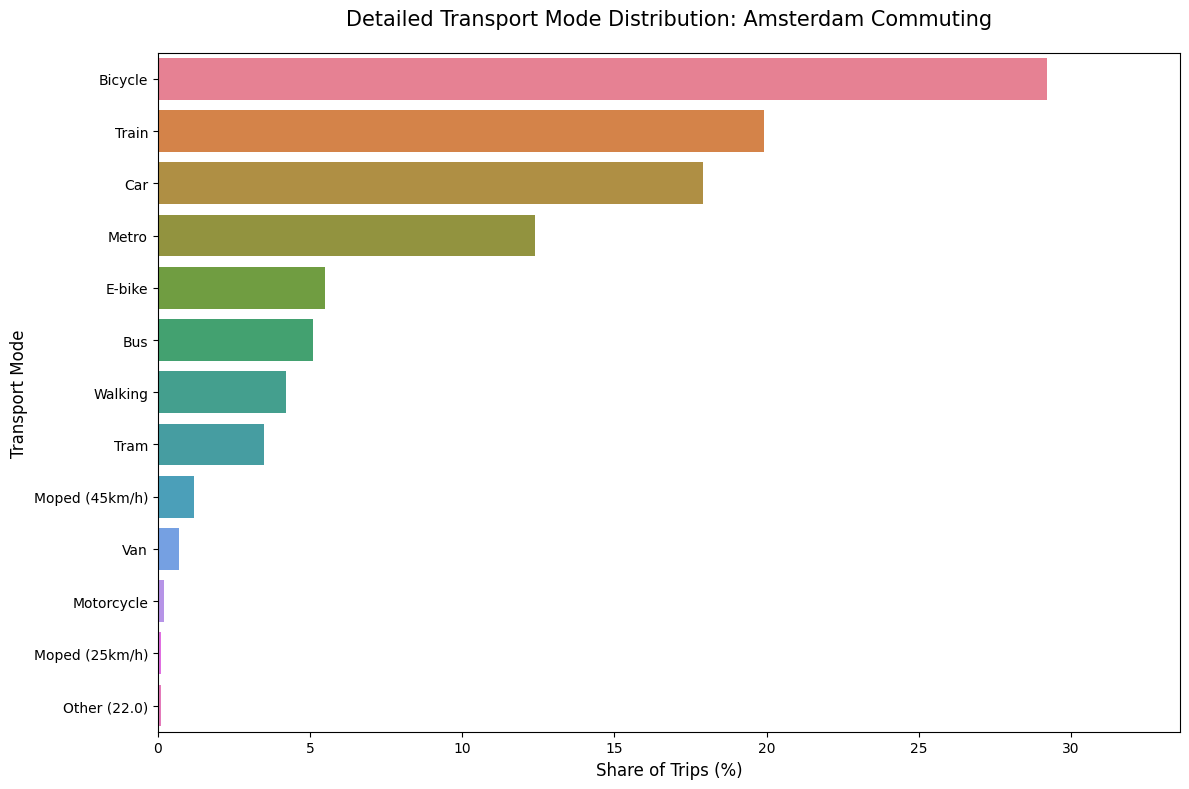

In [282]:
# --- Detailed mode distribution (Hvm) ---
detailed_modes_codes = {
    1.0: "Car", 2.0: "Train", 3.0: "Bus", 4.0: "Tram",
    5.0: "Metro", 6.0: "Speedpedelec", 7.0: "E-bike",
    8.0: "Bicycle", 9.0: "Walking", 10.0: "Coach",
    11.0: "Van", 14.0: "Taxi", 16.0: "Motorcycle",
    17.0: "Moped (45km/h)", 18.0: "Moped (25km/h)"
}


dtl_mode_counts = base_amst_data.mode_detailed.value_counts().sort_index() # count trips per detailed transport mode class 
dtl_mode_pct    = (dtl_mode_counts / len(base_amst_data) * 100).round(1) #count the pct for each detailed transport mode class
dtl_mode_table  = pd.DataFrame({
    "Mode (Detailed)": dtl_mode_counts.index.map(lambda x: detailed_modes_codes.get(x, f"Other ({x})")),
    "Count": dtl_mode_counts.values,
    "Share(%)": dtl_mode_pct.values
})
print("=== Detailed transport mode — Amsterdam commuting ===")
print(dtl_mode_table.to_string(index=False))

print()

plot_dtl = dtl_mode_table.sort_values("Share(%)", ascending = False)

plt.figure(figsize = (12,8))
ax = sns.barplot (
    data = plot_dtl,
    x = "Share(%)",
    y = "Mode (Detailed)",
    hue = "Mode (Detailed)",
    legend = False
)

plt.title('Detailed Transport Mode Distribution: Amsterdam Commuting', fontsize=15, pad=20)
plt.xlabel('Share of Trips (%)', fontsize = 12)
plt.ylabel('Transport Mode', fontsize = 12)
plt.xlim(0, plot_dtl["Share(%)"].max() * 1.15) # Leave room for labels

plt.tight_layout()
plt.show()

=== Detailed transport mode — Amsterdam commuting ===
          Mode Class  Count  Share(%)
        Car - driver    218      15.7
     Car - passenger     31       2.2
               Train    276      19.9
Bus/Tram/Metro (BTM)    292      21.0
             Bicycle    482      34.7
             Walking     58       4.2
               Other     32       2.3



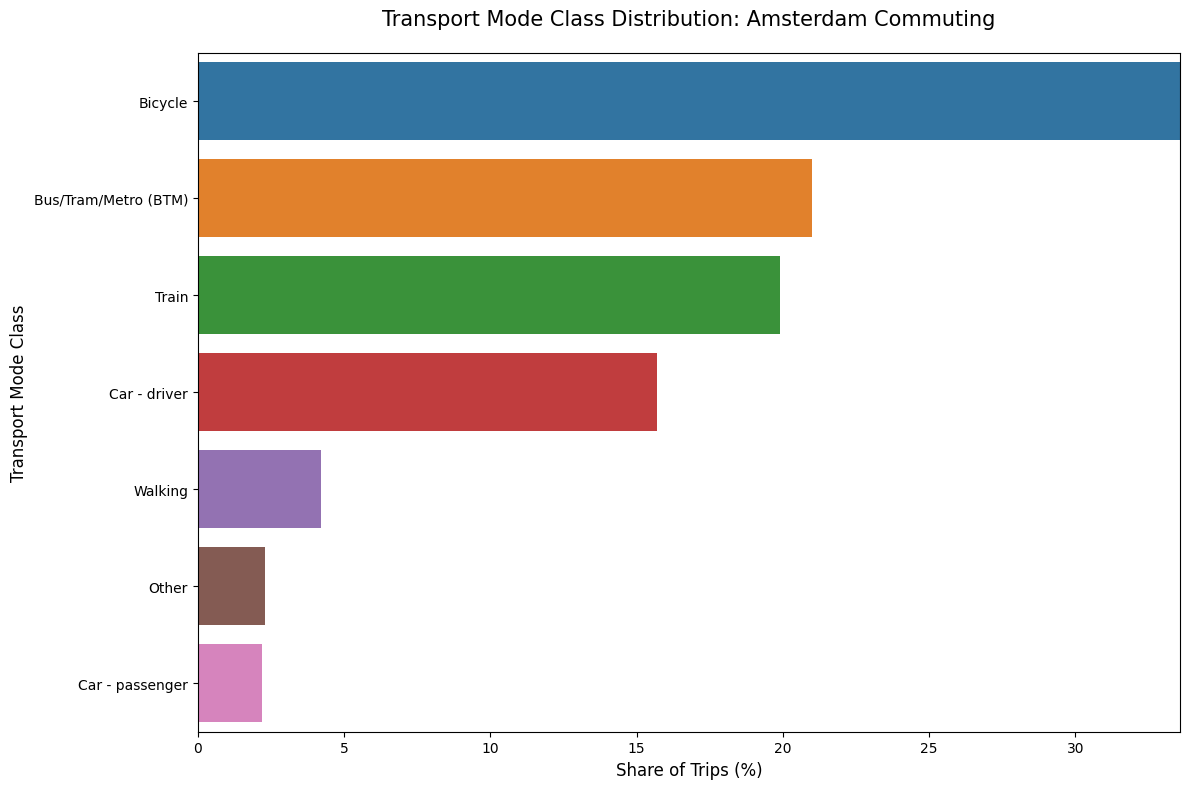

In [284]:
# --- Mode class distribution (KHvm) ---
modes_class_codes = {
    1.0: "Car - driver", 
    2.0: "Car - passenger", 
    3.0: "Train",
    4.0: "Bus/Tram/Metro (BTM)",
    5.0: "Bicycle",
    6.0: "Walking",
    7.0: "Other"
}


cls_mode_counts = base_amst_data.mode_class.value_counts().sort_index() # count trips per transport mode class 
cls_mode_pct    = (cls_mode_counts / len(base_amst_data) * 100).round(1) #count the pct for each transport mode class
cls_mode_table  = pd.DataFrame({
    "Mode Class": cls_mode_counts.index.map(lambda x: modes_class_codes.get(x, f"Other ({x})")),
    "Count": cls_mode_counts.values,
    "Share(%)": cls_mode_pct.values
})
print("=== Detailed transport mode — Amsterdam commuting ===")
print(cls_mode_table.to_string(index=False))

print()

plot_cls = cls_mode_table.sort_values("Share(%)", ascending = False)

plt.figure(figsize = (12,8))
ax = sns.barplot (
    data = plot_cls,
    x = "Share(%)",
    y = "Mode Class",
    hue = "Mode Class",
    legend = False
)

plt.title('Transport Mode Class Distribution: Amsterdam Commuting', fontsize=15, pad=20)
plt.xlabel('Share of Trips (%)', fontsize = 12)
plt.ylabel('Transport Mode Class', fontsize = 12)
plt.xlim(0, plot_dtl["Share(%)"].max() * 1.15) # Leave room for labels

plt.tight_layout()
plt.show()

From the two graphs above we can observe two important things. 

Firstly, within the `mode_class` = 4 class (bus/tram/metro), the detailed variable `mode_detailed`shows that bus (code 3), tram (code 4), and metro (code 5) are all present in the dataset. 

Secondly, the BTM modes (Bus/Tram/Metro) cannot be considered as independent alternatives due tothe following reasons:
1. CBS deliberately aggregates them into a single class in `mode_class` = 4 , reflecting their operational integration under a single fare system (GVB OV-chipkaart).
2. A commuter choosing "public transport" in Amsterdam selects an integrated network, not an individual vehicle type — the route taken on a given day may combine tram and metro legs.
3. Separating them would require trip-level assignment of stops to specific vehicle types, introducing a constructed variable with significant uncertainty. Therefore, for the purposes of this work we are going ot treat bus, tram, and metro as a single Public Transport (PT) alternative. This follows the practice of the CBS codebook itself and is consistent with the Amsterdam GVB network structure.

In [287]:
# Filter to BTM trips only (KHvm == 4)
btm_amst_data = base_amst_data[base_amst_data.mode_class == 4]

btm_detail = btm_amst_data.mode_detailed.value_counts().sort_index()
btm_pct = (btm_detail / len(btm_amst_data) * 100).round(1)

btm_table = pd.DataFrame({
    "Detailed mode": btm_detail.index.map(lambda x: detailed_modes_codes.get(x, f"Code {x}")),
    "Count": btm_detail.values,
    "Share within PT (%)": btm_pct.values
})

print("Composition of BTM code (Public Transport)")
print(f"Total BTM trips: {len(btm_amst_data):,}")
print()
print(btm_table.to_string(index=False))
print()
print("Decision: bus + tram + metro treated as one PT alternative.")

Composition of BTM code (Public Transport)
Total BTM trips: 292

Detailed mode  Count  Share within PT (%)
          Bus     71                 24.3
         Tram     49                 16.8
        Metro    172                 58.9

Decision: bus + tram + metro treated as one PT alternative.
Source justification: ODiN codebook KHvm classification (CBS, 2024).


Finally, we need to filter the base dataset to get only the commuters' trips within the Amsterdam area.    

In [407]:
amst_data = base_amst_data.copy() #create a copy of the base dataset

In [408]:
amst_data.columns

Index(['new_id', 'person_id', 'trip_id', 'new_trip_id', 'home_municipality',
       'origin_municipality', 'dest_municipality', 'origin_postcode',
       'dest_postcode', 'amsterdam_neighborhood', 'trip_purpose',
       'mode_detailed', 'mode_class', 'mode_role', 'month', 'weekday',
       'is_holiday', 'departure_hour', 'departure_minute', 'travel_time_min',
       'distance_hm', 'age', 'gender', 'income_decile', 'has_driving_license',
       'n_cars_household', 'weight_trip', 'weight_person', 'distance_km',
       'is_peak'],
      dtype='object')

In [392]:
# Show all columns (none are hidden with "...")
pd.set_option('display.max_columns', None)

In [412]:
#Filter for regular trips only excluding trip series and freight (cargo) trips new_trip_id = 1 (Duthc name: Verpl)
amst_data = amst_data[amst_data.new_trip_id == 1]

In [413]:
#Filets for trips only in the Amsterdam are, working days and trip_purpose = commutin already applied in the base_mask for the base_amst_data daaset
#We need to filter the trips only for the desired transport mdoes: cars (1.0), public transport (4.0) and bikes (5.0)
keys_to_keep = [1.0, 4.0, 5.0]
choice_set = {k: modes_class_codes[k] for k in keys_to_keep}

amst_data = amst_data[amst_data.mode_class.isin(choice_set)] 

In [416]:
#We need to filter the trips where we have only the driver as a commuter as this is relevant for the mode choice
amst_data = amst_data[~((amst_data.mode_class == 1) & (amst_data.mode_role == 2))]


In [418]:
amst_data.shape

(768, 30)

In [422]:
amst_data.mode_class.value_counts().sort_index()

mode_class
1.0    210
4.0    116
5.0    442
Name: count, dtype: int64

In [ ]:
#Lets define a function for easier filtering and keeping a log of the changes we are making of the dataset

transformation_log = []

def apply_filter(dataset, mask, description):
    """Apply a boolean mask, log the result, return filtered df."""
    n_before = len(dataset)
    dataset_r = dataset[mask].copy()
    n_after  = len(dataset_r)
    n_dropped = n_before - n_after
    entry = f"{description}: {n_before:,} → {n_after:,} rows (dropped {n_dropped:,})"
    transformation_log.append(entry)
    print(entry)
    return dataset_r

# Start from full raw dataset
amst_data = work_data.copy()

# Filter 1: regular trips only (Verpl == 1, excludes trip series and freight)
amst_data = apply_filter(amst_data, amst_data.new_trip_id == 1.0,
                    "F1: Regular trips only (new_trip_id == 1)")

# Filter 2: Amsterdam residential municipality
amst_data = apply_filter(amst_data, amst_data.home_municipality == amsterdam_gem_code,
                    f"F2: Amsterdam residents (home_municipality == {amsterdam_gem_code})")

# Filter 3: commuting purpose only
amst_data = apply_filter(amst_data, amst_data.trip_purpose == commute_code,
                    "F3: Commuting trips (trip_purpose == 1)")

# Filter 4: weekdays only (Mon-Fri)
amst_data = apply_filter(amst_data, amst_data.weekday.isin(weekday_codes),
                    "F4: Working days only (Mon-Fri)")

# Filter 5: exclude public holidays
amst_data = apply_filter(amst_data, amst_data.is_holiday == 0.0,
                    "F5: Exclude public holidays (is_holiday == 0)")

# Filter 6: our three modes only (car driver, PT, bicycle)
amst_data = apply_filter(amst_data, amst_data.mode_class.isin(choice_set),
                    "F6: Choice set modes only (car driver, PT, bicycle)")

# Filter 7: car driver role only (HvmRol == 1 for car, or not applicable)
# Exclude car passengers who were classified as car driver in KHvm (edge cases)
amst_data = apply_filter(
    amst_data,
    ~((amst_data.mode_class == maincode_car_driver) & (amst_data.mode_role == 2.0)),
    "F7: Exclude car passengers misclassified as drivers (mode_role == 2)"
)

## Tidy Data Construction

## Data Cleaning

## Normalisation and features construction

In [247]:

# Lets create a global configuration block sourced from: ODiN2023_Codeboek_v1_0 which we can use during the entire analysis

# # --- File paths ---
# ODIN_RAW_PATH   = Path("data/raw/odin/ODiN2023_Verplaatsingen.sav")
# GTFS_RAW_PATH   = Path("data/raw/gtfs/gtfs-nl.zip")
# ODIN_CLEAN_PATH = Path("data/processed/odin_amsterdam_commute.csv")
# LOS_PATH        = Path("data/processed/los_amsterdam.csv")
# FINAL_PATH      = Path("data/processed/amsterdam_final.csv")
# SAMPLE_PATH     = Path("data/sample/amsterdam_commute_sample.csv")

# --- Geographic filter ---
amsterdam_gem_code = 363      # CBS municipality code for Amsterdam (WoGem)

# --- Trip purpose filter (MotiefV) ---
# Source: ODiN2023 codebook, variable MotiefV
commute_code = 1.0    # 1 = "Van en naar het werk" (commuting)
# Excluded: 2 = "Zakelijk bezoek in werksfeer" (business travel)
# Reason: business trips are often employer-reimbursed, biasing cost coefficients

# --- Weekday filter (Weekdag) ---
# Source: ODiN2023 codebook, variable Weekdag
# 1=Sunday, 2=Monday, 3=Tuesday, 4=Wednesday, 5=Thursday, 6=Friday, 7=Saturday
weekday_codes = [2.0, 3.0, 4.0, 5.0, 6.0]   # Monday to Friday

# --- KHvm: Main mode CLASS codes (used for choice set definition) ---
# Source: ODiN2023 codebook, variable KHvm
maincode_car_driver = 1.0    # Personenauto - bestuurder → alternative: CAR
maincode_pt         = 4.0    # Bus/tram/metro → alternative: PUBLIC TRANSPORT
maincode_bike       = 5.0    # Fiets (e-bike + regular) → alternative: BICYCLE
maincode_walk       = 6.0    # Te voet → EXCLUDED (not a motorised mode)
maincode_other      = 7.0    # Overig → EXCLUDED

# Choice set: the three alternatives in our MNL model
choice_set = [maincode_car_driver, maincode_pt, maincode_bike]

# Hvm: Detailed mode codes (used for BTM analysis only (Bus, Tram, Metro)) ---
# Source: ODiN2023 codebook, variable Hvm
dtcode_car   = 1.0    # Personenauto
dtcode_train = 2.0    # Trein
dtcode_bus   = 3.0    # Bus
dtcode_tram  = 4.0    # Tram
dtcode_metro = 5.0    # Metro
dtcode_ebike = 7.0    # Elektrische fiets
dtcode_bike  = 8.0    # Niet-elektrische fiets
dtcode_walk  = 9.0    # Te voet

# BTM group: detailed modes that map to KHvm==4
btm_codes = [dtcode_bus, dtcode_tram, dtcode_metro]

# --- Distance conversion ---
hm_to_km = 0.1    # AfstV is recorded in hectometers

# --- Cleaning thresholds ---
min_trip_dur = 2 # in mins; below 2mins likely data entry error
max_trip_duration = 120 # in mins; above 120 mins is outside typical Amsterdam urban commute
min_trip_distance = 0.2 # in km; below is unlikely for any of our three modes
max_trip_distance = 50 # in km; above is outside Amsterdam urban area

# --- Peak hour definition ---
am_peak_start = 7 
am_peak_end   = 9
pm_peak_start = 17
pm_peak_end   = 19